In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any
from pathlib import Path

In [36]:
def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        logger.info("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        logger.info("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

In [37]:
df = pd.read_csv("../outputs/figures/predictions/family/nn_predictions_random.csv")

In [38]:
df

,cid,family,seed,n_qubits,n_layers,target,prediction,error
0,random_Q10_L100_S1043314352,random,1043314352,10,100,NaN,7.944593,NaN
1,random_Q10_L100_S1335590972,random,1335590972,10,100,NaN,8.155889,NaN
2,random_Q10_L100_S1351513569,random,1351513569,10,100,NaN,8.098894,NaN
3,random_Q10_L100_S1604721718,random,1604721718,10,100,NaN,8.059867,NaN
4,random_Q10_L100_S181257097,random,181257097,10,100,NaN,8.176008,NaN
...,...,...,...,...,...,...,...,...
13995,random_Q8_L98_S3646560510,random,3646560510,8,98,NaN,6.027684,NaN
13996,random_Q8_L98_S3887894155,random,3887894155,8,98,NaN,6.115730,NaN
13997,random_Q8_L98_S3936027427,random,3936027427,8,98,NaN,6.026467,NaN
13998,random_Q8_L98_S550265526,random,550265526,8,98,NaN,6.003893,NaN


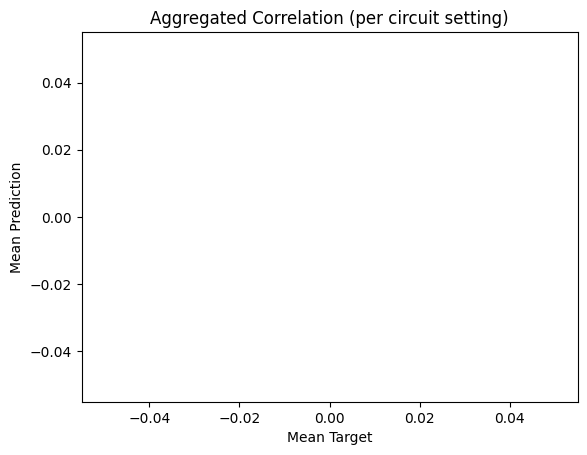

In [39]:
# aggregate over seeds
agg = df.groupby(["family", "n_qubits", "n_layers"]).mean(numeric_only=True).reset_index()

plt.figure()
plt.scatter(agg["target"], agg["prediction"], alpha=0.7)

min_val = agg["target"].min()
max_val = agg["target"].max()
plt.plot([min_val, max_val], [min_val, max_val], "--")

plt.xlabel("Mean Target")
plt.ylabel("Mean Prediction")
plt.title("Aggregated Correlation (per circuit setting)")
plt.show()

In [40]:
cleaned_df = df.dropna(subset=["target", "prediction"])
grouped = cleaned_df.groupby(["family", "n_qubits", "n_layers"])

results = grouped.apply(
    lambda g: g["target"].corr(g["prediction"])
).reset_index(name="corr")

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'. Did you mean 'names'?

In [32]:
results

,family,n_qubits,n_layers,corr
0,clifford,4,2,0.602416
1,clifford,4,4,0.562133
2,clifford,4,6,0.450031
3,clifford,4,8,0.445029
4,clifford,4,10,0.488015
...,...,...,...,...
795,random,10,92,-0.207568
796,random,10,94,-0.069710
797,random,10,96,0.063125
798,random,10,98,0.078104


In [33]:
agg = cleaned_df.groupby(["family", "n_qubits", "n_layers"]).agg({
    "target": "mean",
    "prediction": "mean",
}).reset_index()

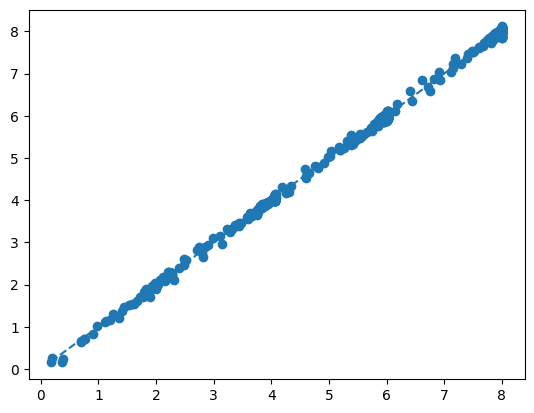

In [34]:
plt.scatter(agg["target"], agg["prediction"])
plt.plot([agg["target"].min(), agg["target"].max()],
         [agg["target"].min(), agg["target"].max()],
         "--")

Text(0, 0.5, 'Absolute Error')

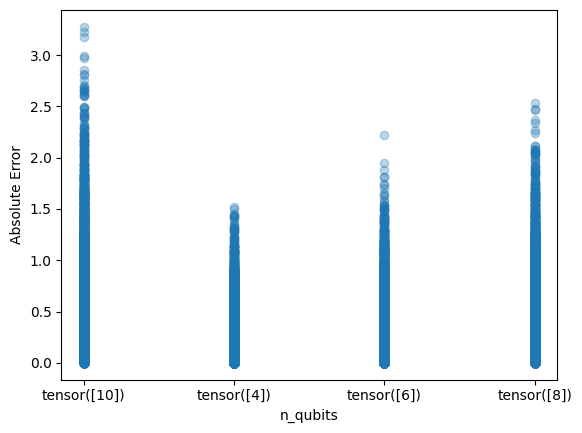

In [67]:
cleaned_df["abs_error"] = (cleaned_df["prediction"] - cleaned_df["target"]).abs()

plt.scatter(cleaned_df["n_qubits"], cleaned_df["abs_error"], alpha=0.3)
plt.xlabel("n_qubits")
plt.ylabel("Absolute Error")

In [68]:
family_df = df.groupby("family").apply(lambda x: x.sample(100))

In [69]:
print(family_df)

                                          cid                  seed  \
family                                                                
clifford 59059    clifford_Q8_L38_S1708655365  tensor([1708655365])   
         13772   clifford_Q12_L74_S2817257749  tensor([2817257749])   
         16057   clifford_Q16_L10_S3674987492  tensor([3674987492])   
         30563    clifford_Q4_L12_S1954469248  tensor([1954469248])   
         25142    clifford_Q26_L2_S1677667565  tensor([1677667565])   
...                                       ...                   ...   
random   219862     random_Q16_L78_S420583601   tensor([420583601])   
         254041      random_Q6_L74_S166367410   tensor([166367410])   
         215181    random_Q12_L18_S1804889825  tensor([1804889825])   
         262351     random_Q8_L44_S2567640914  tensor([2567640914])   
         204524    random_Q10_L24_S1385843082  tensor([1385843082])   

                     n_qubits      n_layers    target  prediction  error  
f

In [70]:
df = family_df

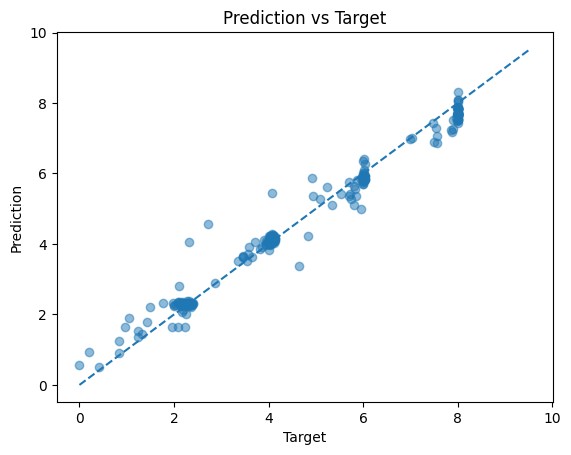

In [71]:
plt.figure()
plt.scatter(df["target"], df["prediction"], alpha=0.5)

# perfect prediction line
min_val = min(df["target"].min(), df["prediction"].min())
max_val = max(df["target"].max(), df["prediction"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Prediction vs Target")
plt.show()

In [72]:
corr = df["target"].corr(df["prediction"])
print("Pearson correlation:", corr)

Pearson correlation: 0.9910664301502787


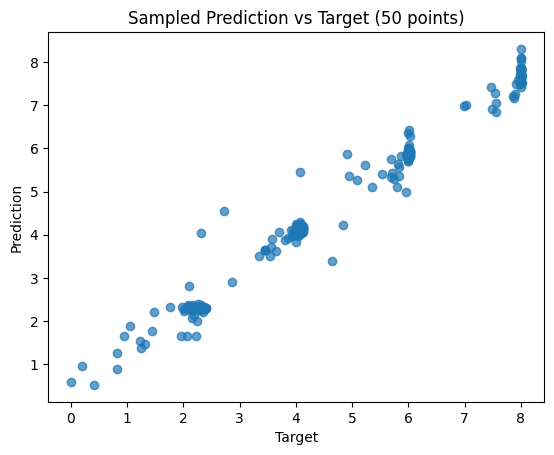

In [73]:
sample = df#.sample(300, random_state=42)

plt.figure()
plt.scatter(sample["target"], sample["prediction"], alpha=0.7)

# diagonal line
min_val = min(sample["target"].min(), sample["prediction"].min())
max_val = max(sample["target"].max(), sample["prediction"].max())
#plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Sampled Prediction vs Target (50 points)")
plt.show()

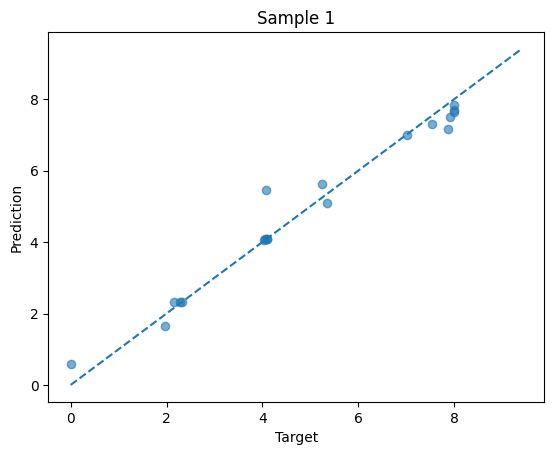

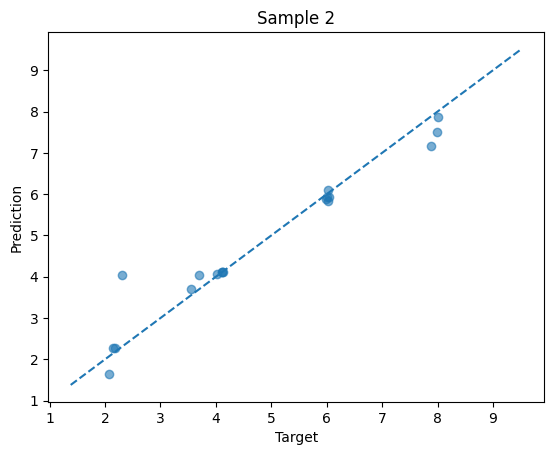

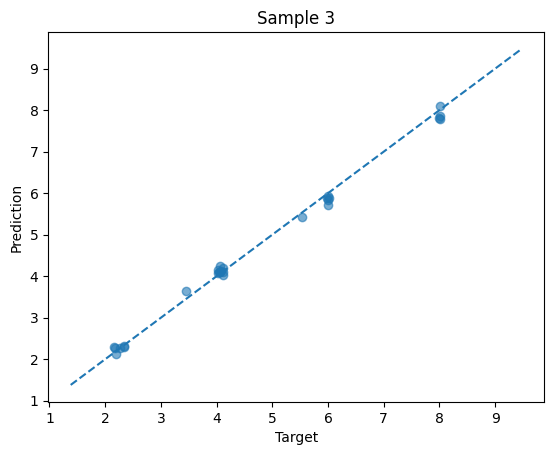

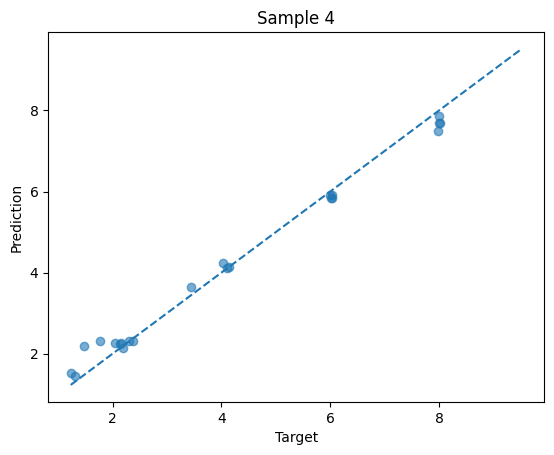

In [74]:
for i in range(4):
    sample = df.sample(30)

    plt.figure()
    plt.scatter(sample["target"], sample["prediction"], alpha=0.6)

    min_val = min(sample["target"].min(), sample["prediction"].min())
    max_val = max(sample["target"].max(), sample["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(f"Sample {i+1}")
    plt.xlabel("Target")
    plt.ylabel("Prediction")
    plt.show()

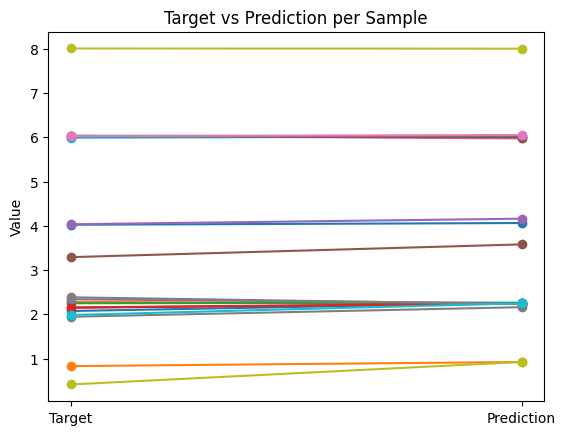

In [75]:
sample = df_clean.sample(20, random_state=0).reset_index(drop=True)

plt.figure()

for i in range(len(sample)):
    plt.plot([0, 1],
             [sample.loc[i, "target"], sample.loc[i, "prediction"]],
             marker="o")

plt.xticks([0, 1], ["Target", "Prediction"])
plt.ylabel("Value")
plt.title("Target vs Prediction per Sample")
plt.show()

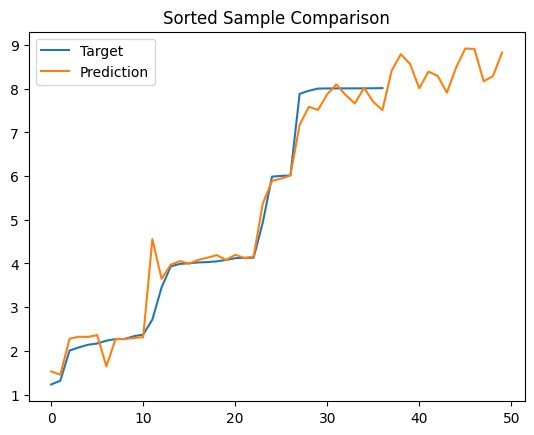

In [76]:
sample = df.sample(50).sort_values("target").reset_index(drop=True)

plt.figure()
plt.plot(sample["target"].values, label="Target")
plt.plot(sample["prediction"].values, label="Prediction")

plt.legend()
plt.title("Sorted Sample Comparison")
plt.show()

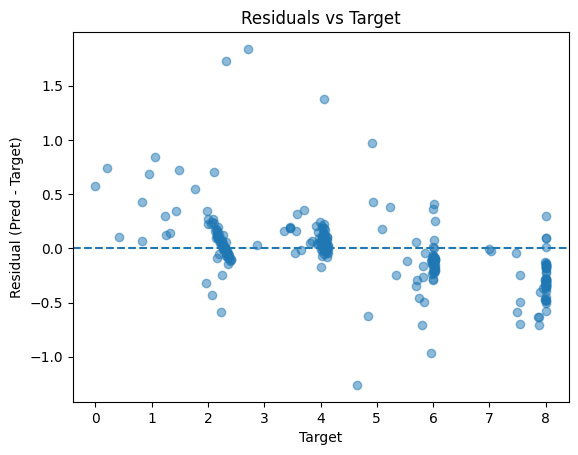

In [77]:
residuals = df["prediction"] - df["target"]

plt.figure()
plt.scatter(df["target"], residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Target")
plt.ylabel("Residual (Pred - Target)")
plt.title("Residuals vs Target")
plt.show()

In [78]:
from sklearn.metrics import r2_score
df_clean = df.dropna(subset=["target", "prediction"])
r2 = r2_score(df_clean["target"], df_clean["prediction"])
print("R²:", r2)

R²: 0.9782340974143595


In [79]:
import seaborn as sns
sns.kdeplot(x=df["target"], y=df["prediction"])



ModuleNotFoundError: No module named 'seaborn'